# 딥러닝실습 팀 프로젝트 — Video Modality

팀: 5조 | 담당: 24011917 이지현  
목표: CMU-MOSI 감성 분석 | 모달리티: 영상(이미지)  
아키텍처: **MTCNN** → EfficientNet-B0 / ResNet-18 → **256-dim feature** (멀티모달 fusion용)

# Part 1. 셋업

In [1]:
import os, random, pickle, time, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet18, ResNet18_Weights,
)
from facenet_pytorch import MTCNN

#plt.rcParams['font.family'] = 'Malgun Gothic'
#plt.rcParams['axes.unicode_minus'] = False

print('torch:', torch.__version__)
print('CUDA :', torch.cuda.is_available())

/data/news_group/newsgroup/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


torch: 2.2.2+cu121
CUDA : True


In [2]:
SEED        = 42
IMG_SIZE    = 224
BATCH_SIZE  = 64
FEATURE_DIM = 256  # 멀티모달 fusion용 출력 차원

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ROOT_PATH    = r'/data/news_group/newsgroup/code/AI/labeling/train/emotion/data'
VIDEO_FOLDER = os.path.join(ROOT_PATH, 'Video', 'Segmented')
LABEL_PATH   = os.path.join(ROOT_PATH, 'mosi_audio_metadata.csv')
PICKLE_PATH  = os.path.join(ROOT_PATH, 'video_preprocessed.pkl')

print(f'device: {device}')
print(f'VIDEO_FOLDER: {VIDEO_FOLDER}')
print(f'PICKLE_PATH: {PICKLE_PATH}')

device: cuda
VIDEO_FOLDER: /data/news_group/newsgroup/code/AI/labeling/train/emotion/data/Video/Segmented
PICKLE_PATH: /data/news_group/newsgroup/code/AI/labeling/train/emotion/data/video_preprocessed.pkl


In [3]:
label_df   = pd.read_csv(LABEL_PATH)

# file_name: '03bSnISJMiM_1.wav' → key: '03bSnISJMiM_1' → label: 1(긍정) / 0(부정)
label_dict = {
    os.path.splitext(r['file_name'])[0]: (1 if r['sentiment'] >= 0 else 0)
    for _, r in label_df.iterrows()
}
print(f'총 라벨 수: {len(label_dict)}')
print(f"긍정: {sum(v==1 for v in label_dict.values())}  "
      f"부정: {sum(v==0 for v in label_dict.values())}")

총 라벨 수: 2199
긍정: 1176  부정: 1023


# Part 2. 전처리 (MTCNN + Pickle 캐싱)

- **MTCNN**: facenet_pytorch 기반 딥러닝 얼굴 탐지 (Haar Cascade 대비 정확도 향상)
- fallback: MTCNN 탐지 실패 시 전체 이미지를 224×224로 리사이즈
- 전처리 결과를 Pickle로 저장해 재실행 시 즉시 로드

In [ ]:
# 캐시 로드 or 새로 생성
if os.path.exists(PICKLE_PATH):
    print('캐시 로드:', PICKLE_PATH)
    with open(PICKLE_PATH, 'rb') as f:
        images, labels = pickle.load(f)
    print(f'이미지: {images.shape}  라벨: {labels.shape}')
    print(f"긍정: {(labels==1).sum()}  부정: {(labels==0).sum()}")
else:
    print('피클 없음 → build_dataset() 실행 필요')
    print('아래 셀을 실행하세요')

캐시 로드: /data/news_group/newsgroup/code/AI/labeling/train/emotion/data/video_preprocessed.pkl
이미지: (2199, 224, 224, 3)  라벨: (2199,)
긍정: 1176  부정: 1023


In [ ]:
mtcnn = MTCNN(image_size=IMG_SIZE, margin=20, keep_all=False,
              device=device, post_process=False)

# CMU-MOSI 영상은 해상도가 제각각 → MTCNN 입력 전 고정 크기로 정규화
MTCNN_INPUT_SIZE = (640, 480)   # 얼굴 탐지용 표준 입력 (출력은 항상 IMG_SIZE×IMG_SIZE)

def extract_middle_frame(video_path):
    """mp4에서 중간 프레임 1장을 PIL Image로 추출."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, max(total // 2, 0))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

def preprocess_video(path):
    """mp4 → 중간 프레임 추출 → MTCNN 얼굴 탐지 → (224,224,3) uint8.

    수정: MTCNN 호출 전에 MTCNN_INPUT_SIZE로 리사이즈하여
         'equal-dimension images' 오류(영상 해상도 불일치) 방지.
    """
    img_pil = extract_middle_frame(path)
    if img_pil is None:
        return None

    # 고정 크기로 통일한 뒤 MTCNN 호출
    img_for_mtcnn = img_pil.resize(MTCNN_INPUT_SIZE, Image.BILINEAR)

    try:
        face = mtcnn(img_for_mtcnn)          # (3, 224, 224) float32 or None
    except Exception as e:
        print(f'  [WARN] MTCNN 실패 ({path}): {e}')
        face = None

    if face is not None:
        img_np = face.clamp(0, 255).permute(1, 2, 0).byte().cpu().numpy()
    else:
        # fallback: 원본 이미지를 직접 리사이즈
        img_np = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    return img_np

def build_dataset():
    all_files = [f for f in os.listdir(VIDEO_FOLDER) if f.endswith('.mp4')]
    
    # 1. 프레임 전부 추출
    valid_keys = []
    frames = []
    for fname in tqdm(all_files, desc='프레임 추출'):
        key = os.path.splitext(fname)[0]
        if key not in label_dict:
            continue
        img_pil = extract_middle_frame(os.path.join(VIDEO_FOLDER, fname))
        if img_pil is None:
            continue
        img_for_mtcnn = img_pil.resize(MTCNN_INPUT_SIZE, Image.BILINEAR)
        valid_keys.append((key, img_pil))
        frames.append(img_for_mtcnn)

    # 2. MTCNN 배치 처리
    MTCNN_BATCH = 64
    images, labels = [], []

    for i in tqdm(range(0, len(frames), MTCNN_BATCH), desc='MTCNN 배치'):
        batch_frames = frames[i:i+MTCNN_BATCH]
        batch_keys   = valid_keys[i:i+MTCNN_BATCH]

        #그래도 안돼서.. 크기 리사이즈 1번 더
        batch_frames = [f.resize(MTCNN_INPUT_SIZE, Image.BILINEAR) for f in batch_frames]


        try:
            faces = mtcnn(batch_frames)   # 리스트 반환
        except Exception as e:
            print(f'[WARN] 배치 MTCNN 실패: {e}')
            faces = [None] * len(batch_frames)

        #다음에 이걸로해보기
        # try:
        #     # MTCNN에 numpy 배열 리스트로 넘기기
        #     batch_np = [np.array(f) for f in batch_frames]
        #     faces = mtcnn(batch_np)
        # except Exception as e:
        #     print(f'[WARN] 배치 MTCNN 실패, 1개씩 처리로 fallback: {e}')
        #     faces = []
        #     for f in batch_frames:
        #         try:
        #             faces.append(mtcnn(np.array(f)))
        #         except:
        #             faces.append(None)

        for face, (key, orig_pil) in zip(faces, batch_keys):
            if face is not None:
                img_np = face.clamp(0, 255).permute(1, 2, 0).byte().cpu().numpy()
            else:
                img_np = np.array(orig_pil.resize((IMG_SIZE, IMG_SIZE)))
            images.append(img_np)
            labels.append(label_dict[key])

    return np.array(images), np.array(labels)

# 캐시 로드 or 새로 생성 
if os.path.exists(PICKLE_PATH):
    print('캐시 로드:', PICKLE_PATH)
    with open(PICKLE_PATH, 'rb') as f:
        images, labels = pickle.load(f)
else:
    images, labels = build_dataset()
    with open(PICKLE_PATH, 'wb') as f:
        pickle.dump((images, labels), f)
    print('피클 저장 완료:', PICKLE_PATH)

print(f'이미지: {images.shape}  라벨: {labels.shape}')
print(f"긍정: {(labels==1).sum()}  부정: {(labels==0).sum()}")

# Part 3. DataLoader

- **GaussianNoise**: train 전용 텐서 노이즈 증강 (std=0.05)
- 기존 증강(flip, rotation, colorjitter, affine) 유지
- stratified 80/20 split

In [19]:
class GaussianNoise:
    """Tensor에 가우시안 노이즈를 추가하는 커스텀 transform."""
    def __init__(self, std=0.05):
        self.std = std
    def __call__(self, t):
        return (t + torch.randn_like(t) * self.std).clamp(0, 1)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    GaussianNoise(std=0.05),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

#  train 64% / val 16% / test 20% 
X_tr, X_test, y_tr, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=SEED, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=0.2, random_state=SEED, stratify=y_tr
)

g = torch.Generator(); g.manual_seed(SEED)

#  num_workers=2, persistent_workers=True / 근데 worker 수 늘렸을 때 저하되면 0으로..
NW = 2
train_loader = DataLoader(ImageDataset(X_train, y_train, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,
                          generator=g, num_workers=NW,
                          pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(ImageDataset(X_val, y_val, val_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(ImageDataset(X_test, y_test, test_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True, persistent_workers=True)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  Test batches: {len(test_loader)}')


Train: 1407  Val: 352  Test: 440
Train batches: 22  Val batches: 6  Test batches: 7


# Part 4. 모델 정의 — VideoEncoder

efficientnet:1280-dim → 256-dim   
resnet18: 512-dim → 256-dim

- `feature_only=False` (기본): 분류 logit 반환 → 단독 학습/평가
- `feature_only=True`: 256-dim 벡터 반환 → 멀티모달 fusion 입력

In [7]:
class VideoEncoder(nn.Module):
    """EfficientNet-B0 또는 ResNet-18 기반 영상 인코더.
    feature_only=True → 256-dim 벡터 (멀티모달 fusion용)."""

    def __init__(self, backbone='efficientnet', num_classes=2, feature_dim=FEATURE_DIM):
        super().__init__()
        if backbone == 'efficientnet':
            base   = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
            in_dim = base.classifier[1].in_features   # 1280
            base.classifier = nn.Identity()
        elif backbone == 'resnet18':
            base   = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
            in_dim = base.fc.in_features              # 512
            base.fc = nn.Identity()
        else:
            raise ValueError(f'Unknown backbone: {backbone}')

        self.backbone   = base
        # [Fix 5] BatchNorm + Dropout 추가
        self.proj       = nn.Sequential(
            nn.Linear(in_dim, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x, feature_only=False):
        feat = self.proj(self.backbone(x))   # (B, 256)
        return feat if feature_only else self.classifier(feat)

    def extract_features(self, loader, device):
        """전체 데이터셋 256-dim 피처 추출 (멀티모달용)."""
        self.eval()
        feats, ys = [], []
        with torch.no_grad():
            for x, y in tqdm(loader, desc='feature extraction'):
                feats.append(self.forward(x.to(device), feature_only=True).cpu())
                ys.append(y)
        return torch.cat(feats), torch.cat(ys)


for name, bk in [('EfficientNet-B0', 'efficientnet'), ('ResNet-18', 'resnet18')]:
    m     = VideoEncoder(backbone=bk)
    total = sum(p.numel() for p in m.parameters())
    print(f'{name}: {total:,} params')
    del m


EfficientNet-B0: 4,336,510 params
ResNet-18: 11,308,866 params


# Part 5. 랜덤 서치

In [8]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / total, correct / total


def run_search(backbone, param_space, n_search, train_loader, val_loader, device):
    """[Fix 1] val_loader로 하이퍼파라미터 탐색 (test leakage 방지).
    [Fix 2] 최고 성능 모델 state_dict 저장 후 반환."""
    criterion = nn.CrossEntropyLoss()
    all_combos = [
        (lr, ep, opt, wd)
        for lr  in param_space['lr']
        for ep  in param_space['num_epochs']
        for opt in param_space['optimizer']
        for wd  in param_space['weight_decay']
    ]
    configs  = random.sample(all_combos, min(n_search, len(all_combos)))
    results  = []
    best_acc, best_cfg, best_state = 0.0, {}, None

    for i, (lr, ep, opt_name, wd) in enumerate(configs):
        model = VideoEncoder(backbone=backbone).to(device)
        optimizer = (
            optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
            if opt_name == 'Adam'
            else optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
        )
        t0 = time.time()
        for ep_i in range(1, ep + 1):
            _,tr_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
            _, val_acc = run_epoch(model, val_loader, criterion, None, device, train=False)
            print(f'  Epoch {ep_i}/{ep}  train={tr_acc:.4f}  val={val_acc:.4f}')
        elapsed = time.time() - t0

        print(f'[{backbone}] {i+1}/{len(configs)} '
              f'lr={lr} ep={ep} {opt_name} wd={wd} '
              f'→ val_acc={val_acc:.4f} ({elapsed:.0f}s)')

        rec = {'backbone': backbone, 'lr': lr, 'num_epochs': ep,
               'optimizer': opt_name, 'weight_decay': wd,
               'val_acc': round(val_acc, 4)}
        results.append(rec)
        # [Fix 2] 베스트 모델 state_dict 저장
        if val_acc > best_acc:
            best_acc, best_cfg = val_acc, rec.copy()
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        del model; torch.cuda.empty_cache()

    return pd.DataFrame(results).sort_values('val_acc', ascending=False), best_cfg, best_state


In [10]:
PARAM_SPACE = {
    'lr'          : [5e-4, 3e-4, 1e-4],  # 1e-3 제거
    'num_epochs'  : [10, 15],
    'optimizer'   : ['Adam'],
    'weight_decay': [1e-3, 5e-3],        # 정규화 더 강하게
}
N_SEARCH = 10

random.seed(SEED)
print('=== EfficientNet-B0 Random Search ===')
eff_results, eff_best, eff_best_state = run_search(
    'efficientnet', PARAM_SPACE, N_SEARCH, train_loader, val_loader, device
)
print(f'\n★ EfficientNet-B0 최적 (val): {eff_best}')


=== EfficientNet-B0 Random Search ===
  Epoch 1/15  train=0.5387  val=0.4915
  Epoch 2/15  train=0.5842  val=0.5057
  Epoch 3/15  train=0.6063  val=0.4602
  Epoch 4/15  train=0.6297  val=0.4943
  Epoch 5/15  train=0.6446  val=0.5227
  Epoch 6/15  train=0.6631  val=0.4773
  Epoch 7/15  train=0.6823  val=0.4688
  Epoch 8/15  train=0.6830  val=0.4602
  Epoch 9/15  train=0.6681  val=0.4545
  Epoch 10/15  train=0.7008  val=0.4631
  Epoch 11/15  train=0.7036  val=0.4943
  Epoch 12/15  train=0.7065  val=0.4915
  Epoch 13/15  train=0.7001  val=0.4773
  Epoch 14/15  train=0.6802  val=0.5085
  Epoch 15/15  train=0.7200  val=0.4460
[efficientnet] 1/10 lr=0.0001 ep=15 Adam wd=0.001 → val_acc=0.4460 (39s)
  Epoch 1/10  train=0.5515  val=0.4886
  Epoch 2/10  train=0.6212  val=0.5369
  Epoch 3/10  train=0.6326  val=0.5000
  Epoch 4/10  train=0.6617  val=0.5057
  Epoch 5/10  train=0.6844  val=0.5170
  Epoch 6/10  train=0.6908  val=0.5256
  Epoch 7/10  train=0.6894  val=0.4716
  Epoch 8/10  train=0.687

In [11]:
random.seed(SEED)
print('=== ResNet-18 Random Search ===')
res_results, res_best, res_best_state = run_search(
    'resnet18', PARAM_SPACE, N_SEARCH, train_loader, val_loader, device
)
print(f'\n★ ResNet-18 최적 (val): {res_best}')


=== ResNet-18 Random Search ===
  Epoch 1/15  train=0.5494  val=0.5824
  Epoch 2/15  train=0.6134  val=0.5540
  Epoch 3/15  train=0.6567  val=0.5710
  Epoch 4/15  train=0.6603  val=0.6080
  Epoch 5/15  train=0.6844  val=0.5824
  Epoch 6/15  train=0.6937  val=0.5852
  Epoch 7/15  train=0.6944  val=0.5824
  Epoch 8/15  train=0.6859  val=0.5767
  Epoch 9/15  train=0.7029  val=0.5852
  Epoch 10/15  train=0.7193  val=0.5625
  Epoch 11/15  train=0.7377  val=0.6108
  Epoch 12/15  train=0.7306  val=0.5966
  Epoch 13/15  train=0.7527  val=0.6193
  Epoch 14/15  train=0.7541  val=0.5710
  Epoch 15/15  train=0.7697  val=0.5710
[resnet18] 1/10 lr=0.0001 ep=15 Adam wd=0.001 → val_acc=0.5710 (26s)
  Epoch 1/10  train=0.5302  val=0.5795
  Epoch 2/10  train=0.5856  val=0.5568
  Epoch 3/10  train=0.6169  val=0.5483
  Epoch 4/10  train=0.6205  val=0.5597
  Epoch 5/10  train=0.6247  val=0.5653
  Epoch 6/10  train=0.6361  val=0.6250
  Epoch 7/10  train=0.6226  val=0.5511
  Epoch 8/10  train=0.6340  val=0.6

In [12]:
all_results = pd.concat([eff_results, res_results]).reset_index(drop=True)
print(all_results.to_string(index=False))

    backbone     lr  num_epochs optimizer  weight_decay  val_acc
efficientnet 0.0003          15      Adam         0.001   0.5511
efficientnet 0.0005          15      Adam         0.001   0.5398
efficientnet 0.0005          10      Adam         0.001   0.5312
efficientnet 0.0005          10      Adam         0.005   0.5227
efficientnet 0.0003          10      Adam         0.001   0.5085
efficientnet 0.0005          15      Adam         0.005   0.5085
efficientnet 0.0001          15      Adam         0.005   0.5085
efficientnet 0.0001          10      Adam         0.005   0.4858
efficientnet 0.0001          10      Adam         0.001   0.4631
efficientnet 0.0001          15      Adam         0.001   0.4460
    resnet18 0.0003          15      Adam         0.001   0.6420
    resnet18 0.0005          10      Adam         0.001   0.6193
    resnet18 0.0001          15      Adam         0.005   0.5938
    resnet18 0.0001          10      Adam         0.001   0.5909
    resnet18 0.0005      

# Part 6. 최적 파라미터로 최종 학습

In [13]:
def train_full(backbone, cfg, train_loader, val_loader, test_loader, device, extra_epochs=10):
    """best_state 로드 없이 처음부터 재학습 — epoch은 cfg + extra_epochs."""
    model = VideoEncoder(backbone=backbone).to(device)  # 처음부터
    criterion = nn.CrossEntropyLoss()
    wd = cfg.get('weight_decay', 0)
    optimizer = (
        optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=wd)
        if cfg['optimizer'] == 'Adam'
        else optim.SGD(model.parameters(), lr=cfg['lr'], momentum=0.9, weight_decay=wd)
    )
    # lr scheduler 추가
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['num_epochs'] + extra_epochs
    )

    total_epochs = cfg['num_epochs'] + extra_epochs
    train_accs, val_accs, test_accs = [], [], []
    best_val, best_state = 0.0, None

    for ep in range(1, total_epochs + 1):
        _, tr_acc  = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        _, val_acc = run_epoch(model, val_loader,   criterion, None,      device, train=False)
        _, te_acc  = run_epoch(model, test_loader,  criterion, None,      device, train=False)
        scheduler.step()
        train_accs.append(tr_acc); val_accs.append(val_acc); test_accs.append(te_acc)
        print(f'  Epoch {ep}/{total_epochs}  train={tr_acc:.4f}  val={val_acc:.4f}  test={te_acc:.4f}')

        # val 기준 best 모델 저장
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # best val 모델로 복원
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, train_accs, val_accs, test_accs

In [14]:
print(f'=== EfficientNet-B0 최종 학습 ===')
print(f'config: {eff_best}')
eff_model, eff_tr_accs, eff_val_accs, eff_te_accs = train_full(
    'efficientnet', eff_best, train_loader, val_loader, test_loader, device
)

=== EfficientNet-B0 최종 학습 ===
config: {'backbone': 'efficientnet', 'lr': 0.0003, 'num_epochs': 15, 'optimizer': 'Adam', 'weight_decay': 0.001, 'val_acc': 0.5511}
  Epoch 1/25  train=0.5487  val=0.5114  test=0.4477
  Epoch 2/25  train=0.6148  val=0.4773  test=0.4886
  Epoch 3/25  train=0.6532  val=0.4659  test=0.4773
  Epoch 4/25  train=0.6695  val=0.4943  test=0.4886
  Epoch 5/25  train=0.6930  val=0.5199  test=0.5250
  Epoch 6/25  train=0.6844  val=0.5142  test=0.5205
  Epoch 7/25  train=0.7022  val=0.5284  test=0.5273
  Epoch 8/25  train=0.7058  val=0.5057  test=0.4977
  Epoch 9/25  train=0.7136  val=0.5085  test=0.5114
  Epoch 10/25  train=0.7313  val=0.4972  test=0.5341
  Epoch 11/25  train=0.7413  val=0.5256  test=0.5227
  Epoch 12/25  train=0.7477  val=0.5369  test=0.5068
  Epoch 13/25  train=0.7619  val=0.5000  test=0.5159
  Epoch 14/25  train=0.7726  val=0.4972  test=0.5023
  Epoch 15/25  train=0.7839  val=0.4545  test=0.4682
  Epoch 16/25  train=0.7910  val=0.5256  test=0.4886

In [15]:
print(f'=== ResNet-18 최종 학습 ===')
print(f'config: {res_best}')
res_model, res_tr_accs, res_val_accs, res_te_accs = train_full(
    'resnet18', res_best, train_loader, val_loader, test_loader, device
)


=== ResNet-18 최종 학습 ===
config: {'backbone': 'resnet18', 'lr': 0.0003, 'num_epochs': 15, 'optimizer': 'Adam', 'weight_decay': 0.001, 'val_acc': 0.642}
  Epoch 1/25  train=0.5608  val=0.5028  test=0.5045
  Epoch 2/25  train=0.6127  val=0.5824  test=0.5614
  Epoch 3/25  train=0.6482  val=0.5966  test=0.5545
  Epoch 4/25  train=0.6375  val=0.5881  test=0.5636
  Epoch 5/25  train=0.6759  val=0.5653  test=0.5591
  Epoch 6/25  train=0.6844  val=0.6392  test=0.6295
  Epoch 7/25  train=0.6795  val=0.6080  test=0.5818
  Epoch 8/25  train=0.7058  val=0.5881  test=0.6136
  Epoch 9/25  train=0.7086  val=0.6222  test=0.6114
  Epoch 10/25  train=0.7221  val=0.5966  test=0.5886
  Epoch 11/25  train=0.7448  val=0.6278  test=0.6295
  Epoch 12/25  train=0.7477  val=0.6051  test=0.6364
  Epoch 13/25  train=0.7711  val=0.6136  test=0.6136
  Epoch 14/25  train=0.7711  val=0.6136  test=0.6341
  Epoch 15/25  train=0.7918  val=0.5938  test=0.5909
  Epoch 16/25  train=0.8109  val=0.6506  test=0.6364
  Epoch 17

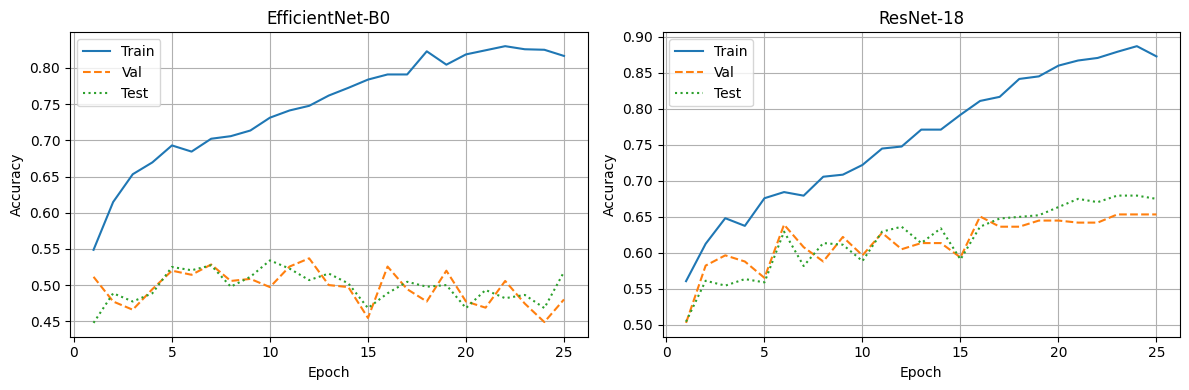

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, tr, val, te in [
    (axes[0], 'EfficientNet-B0', eff_tr_accs, eff_val_accs, eff_te_accs),
    (axes[1], 'ResNet-18',       res_tr_accs, res_val_accs, res_te_accs),
]:
    eps = range(1, len(tr) + 1)
    ax.plot(eps, tr,  label='Train')
    ax.plot(eps, val, label='Val',  linestyle='--')
    ax.plot(eps, te,  label='Test', linestyle=':')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('viz_accuracy_curves.png', dpi=150)
plt.show()


In [17]:
label_names = ['Negative', 'Positive']

for name, model in [('EfficientNet-B0', eff_model), ('ResNet-18', res_model)]:
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().tolist())
            targets.extend(y.tolist())
    print(f'=== {name} (test_acc={sum(p==t for p,t in zip(preds,targets))/len(targets):.4f}) ===')
    print(classification_report(targets, preds, target_names=label_names))

=== EfficientNet-B0 (test_acc=0.5068) ===
              precision    recall  f1-score   support

    Negative       0.47      0.40      0.43       205
    Positive       0.53      0.60      0.56       235

    accuracy                           0.51       440
   macro avg       0.50      0.50      0.50       440
weighted avg       0.50      0.51      0.50       440

=== ResNet-18 (test_acc=0.6795) ===
              precision    recall  f1-score   support

    Negative       0.79      0.43      0.56       205
    Positive       0.64      0.90      0.75       235

    accuracy                           0.68       440
   macro avg       0.71      0.66      0.65       440
weighted avg       0.71      0.68      0.66       440



# Part 7. 256-dim 피처 추출 (멀티모달 Fusion 준비)

선택된 모델: ResNet-18 (val_acc=0.6534  test_acc=0.6795)


feature extraction: 100%|██████████| 35/35 [00:01<00:00, 33.83it/s]



피처 shape: torch.Size([2199, 256])  →  (N, 256)
멀티모달 fusion 시 이 텐서를 audio/text 피처와 concat하세요.


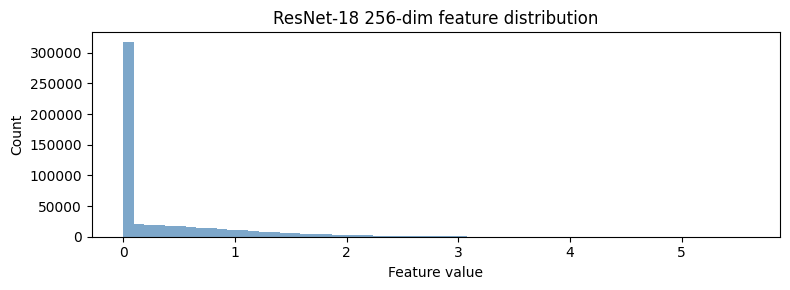

피처 저장: /data/news_group/newsgroup/code/AI/labeling/train/emotion/data/video_features_256.pkl


In [ ]:
# val_acc 기준으로 모델 선택
if max(eff_val_accs) >= max(res_val_accs):
    best_model_name, best_model = 'EfficientNet-B0', eff_model
else:
    best_model_name, best_model = 'ResNet-18', res_model

final_val_acc  = max(eff_val_accs  if best_model_name == 'EfficientNet-B0' else res_val_accs)
final_test_acc = max(eff_te_accs   if best_model_name == 'EfficientNet-B0' else res_te_accs)
print(f'선택된 모델: {best_model_name} (val_acc={final_val_acc:.4f}  test_acc={final_test_acc:.4f})')

# 전체 데이터셋 256-dim 피처 추출
all_loader = DataLoader(
    ImageDataset(images, labels, test_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NW, persistent_workers=True
)
video_feats, video_labels = best_model.extract_features(all_loader, device)

print(f'\n피처 shape: {video_feats.shape}  →  (N, {FEATURE_DIM})')
print('멀티모달 fusion 시 이 텐서를 audio/text 피처와 concat')

# 피처 분포 시각화
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(video_feats.numpy().flatten(), bins=60, color='steelblue', alpha=0.7)
ax.set_title(f'{best_model_name} 256-dim feature distribution')
ax.set_xlabel('Feature value'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('viz_feature_dist.png', dpi=150)
plt.show()

# 피클로 저장 (멀티모달 학습 시 재사용)
feat_save_path = os.path.join(ROOT_PATH, 'video_features_256.pkl')
with open(feat_save_path, 'wb') as f:
    pickle.dump({'features': video_feats, 'labels': video_labels}, f)
print(f'피처 저장: {feat_save_path}')


In [ ]:
# 그래도 67점정도 나온 데이터셋 활용 (mid 때와 유사) -> 추후 freeze도 테스트해보겠습니다..